# Segmented TSP - Ant Colony Optimizations


In [38]:
%pip install requests folium numpy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import requests
import numpy as np
import folium
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
from pathlib import Path

random.seed(42)
np.random.seed(42)

OSRM_BASE = "https://router.project-osrm.org"
PROFILE = "driving"
RETURN_TO_DEPOT = True


In [40]:
NUM_VEHICLES = 5
RETURN_TO_DEPOT = True
ASSIGNMENT_STRATEGY = 'geographic'
WATER_CSV_PATH = "../Dataset/water.csv"
WATER_ASSIGNMENT_STRATEGY = 'nearest'

# Fleet: 3 truk 4000L (V1-V3), 2 truk 8000L (V4-V5)
VEHICLE_CAPACITIES = [4000, 4000, 4000, 8000, 8000]
TANK_CAPACITY = max(VEHICLE_CAPACITIES)  # untuk kompatibilitas fungsi lama

# ...
print(f"Multi-vehicle mode: {NUM_VEHICLES} vehicles, strategy={ASSIGNMENT_STRATEGY}")
print(f"Water source file : {WATER_CSV_PATH}")
print(f"Fleet capacities  : {VEHICLE_CAPACITIES} liters")

Multi-vehicle mode: 5 vehicles, strategy=geographic
Water source file : ../Dataset/water.csv
Fleet capacities  : [4000, 4000, 4000, 8000, 8000] liters


## 1. Define Depot and Load Data from CSV

Each park is a **segment** with `start_lat`, `start_lon`, `end_lat`, `end_lon`, and a `demand` column (liters of water needed). Water sources are loaded from a separate CSV.


In [41]:
DEPOT = (-7.278358153631059, 112.76325243881848)
CSV_PATH = "../Dataset/parks-demand-53.csv"

REQUIRED_COLUMNS = ["start_lat", "start_lon", "end_lat", "end_lon"]
df_segments = pd.read_csv(CSV_PATH)

for col in ["length (m)", "width (m)", "area (m2)", "demand"]:
    if col in df_segments.columns:
        df_segments[col] = (
            df_segments[col].astype(str)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

missing_cols = [c for c in REQUIRED_COLUMNS if c not in df_segments.columns]
if missing_cols:
    raise ValueError(f"CSV is missing required columns: {missing_cols}")

def build_segment_name(row, idx):
    if "id" in row.index and pd.notna(row["id"]):
        return str(row["id"])
    return f"Segment {idx + 1}"

PLANTS = []
for idx, row in df_segments.iterrows():
    demand_val = float(row["demand"]) if "demand" in row.index and pd.notna(row["demand"]) else 0.0
    PLANTS.append({
        "name":      build_segment_name(row, idx),
        "start_lat": float(row["start_lat"]),
        "start_lon": float(row["start_lon"]),
        "end_lat":   float(row["end_lat"]),
        "end_lon":   float(row["end_lon"]),
        "demand":    demand_val,
    })

print(f"Loaded {len(PLANTS)} park segments from {CSV_PATH}")
display(df_segments.head(10))

WATER_REQUIRED_COLS = ["water_id", "lat", "lon"]
df_water = pd.read_csv(WATER_CSV_PATH)
missing_water_cols = [c for c in WATER_REQUIRED_COLS if c not in df_water.columns]
if missing_water_cols:
    raise ValueError(f"Water source CSV is missing columns: {missing_water_cols}")

WATER_SOURCES = []
for _, row in df_water.iterrows():
    WATER_SOURCES.append({
        "water_id": str(row["water_id"]).strip(),
        "lat":      float(row["lat"]),
        "lon":      float(str(row["lon"]).strip()),
    })

print(f"Loaded {len(WATER_SOURCES)} water source(s) from {WATER_CSV_PATH}")
display(df_water)

total_demand = sum(p["demand"] for p in PLANTS)
print(f"\nTotal demand across all segments: {total_demand:,.0f} liters")
print(f"Avg demand per segment: {total_demand / len(PLANTS):,.0f} liters")
print(f"Tank capacity: {TANK_CAPACITY} liters")
print(f"Min refills needed (fleet): {math.ceil(total_demand / TANK_CAPACITY)}")


Loaded 54 park segments from ../Dataset/parks-demand-53.csv


,id,start_lat,start_lon,end_lat,end_lon,length (m),width (m),area (m2),demand
0,Jalan Raya Mulyosari,-7.258301,112.795617,-7.273659,112.797714,575.0,2.0,1150.0,1725.0
1,Jalan Raya Kertajaya Indah (ITS - Oakwood),-7.279408,112.789619,-7.280560,112.781162,950.0,9.0,8550.0,12825.0
2,Jalan Raya Kertajaya Indah - Manyar Kertoarjo,-7.280611,112.780693,-7.279390,112.762482,2000.0,10.0,20000.0,30000.0
3,Jalan Kertajaya,-7.279360,112.762112,-7.278325,112.756143,660.0,9.0,5940.0,8910.0
4,Jalan Kertajaya (Viaduct),-7.278264,112.755534,-7.277394,112.750760,525.0,9.0,4725.0,7087.5
5,Jalan Doktor Insinyur Haji Soekarno,-7.250032,112.784244,-7.254943,112.782404,578.0,7.0,4046.0,6069.0
6,Jalan Kalijudan,-7.255050,112.782372,-7.263295,112.783069,935.0,7.0,6545.0,9817.5
7,Jalan Doktor Insinyur Haji Soekarno,-7.263567,112.783061,-7.269811,112.782163,700.0,4.5,3150.0,4725.0
8,Jalan Doktor Insinyur Haji Soekarno,-7.270306,112.782088,-7.280379,112.780881,1000.0,5.0,5000.0,7500.0
9,Jalan Doktor Insinyur Haji Soekarno,-7.280842,112.780886,-7.289343,112.780610,870.0,4.0,3480.0,5220.0


Loaded 9 water source(s) from ../Dataset/water.csv


,water_id,lat,lon
0,Selokan Depan Perumahan YKP Pandugo,-7.320818,112.789714
1,Selokan Depan Samator,-7.309816,112.773894
2,Selokan Dekat Pizza Hut Merr,-7.297944,112.782019
3,Selokan Dharmahusada Indah,-7.277584,112.772274
4,Sungai Depan ITATS,-7.289701,112.778826
5,Sungai Wisma Permai,-7.274711,112.793570
6,Selokan Dekat Resto Niki Sae,-7.272806,112.781376
7,Sungai Depan SPBU Manyar (Dekat RS Bedah),-7.280928,112.771908
8,Sungai Seberang Apartemen Gunawangsa Menur,-7.289537,112.768956



Total demand across all segments: 289,696 liters
Avg demand per segment: 5,365 liters
Tank capacity: 8000 liters
Min refills needed (fleet): 37


## 1.5 Road Type Classification & Service Time

Classify each segment using the OSM **Overpass API** `highway` tag:
- `arterial` (primary, secondary, trunk, motorway, etc.) — **restricted during rush hour 06:30–07:30**
- `residential` (residential, living_street, service, etc.) — **always allowed within operating hours**

Service time per segment is computed as `demand (L) / FLOW_RATE_LPM` (minutes).
Both attributes are added to every segment dict and displayed in a summary table.

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1.5 – Road Type Classification (OSM Overpass) & Service Time
# ─────────────────────────────────────────────────────────────────────────────

import math
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- Pump flow rate assumption ---
FLOW_RATE_LPM = 500.0   # liters per minute (standard water-truck pump capacity)

# --- OSM highway tags that count as arterial / restricted during rush hour ---
ARTERIAL_TAGS = {
    'motorway', 'motorway_link',
    'trunk', 'trunk_link',
    'primary', 'primary_link',
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
}

# --- Residential / always-allowed tags ---
RESIDENTIAL_TAGS = {
    'residential', 'living_street', 'service',
    'unclassified', 'pedestrian', 'track', 'path',
}

OVERPASS_URL = "https://overpass-api.de/api/interpreter"


# ── Helper: Haversine distance ────────────────────────────────────────────────
def _haversine(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Return distance in metres between two lat/lon points."""
    R = 6_371_000
    φ1, φ2 = math.radians(lat1), math.radians(lat2)
    dφ = math.radians(lat2 - lat1)
    dλ = math.radians(lon2 - lon1)
    a = math.sin(dφ / 2) ** 2 + math.cos(φ1) * math.cos(φ2) * math.sin(dλ / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


# ── Helper: nearest highway tag from an Overpass element pool ────────────────
def _find_nearest_highway(elements: list, lat: float, lon: float) -> str | None:
    """
    From a pool of Overpass way elements (must include 'center'),
    return the highway tag of the closest way to (lat, lon).
    """
    best_tag, best_dist = None, float('inf')
    for el in elements:
        center = el.get('center', {})
        if not center:
            continue
        dist = _haversine(lat, lon, center['lat'], center['lon'])
        if dist < best_dist:
            best_dist = dist
            best_tag = el.get('tags', {}).get('highway')
    return best_tag


# ── Primary strategy: single batch query ─────────────────────────────────────
def query_highway_tags_batch(plants: list[dict], radius_m: int = 30, timeout: int = 60) -> dict:
    """
    Query ALL segment midpoints in ONE Overpass request.
    Returns dict: {(rounded_lat, rounded_lon): highway_tag | None}
    """
    seen      = set()
    key_map   = {}          # cache_key -> (mid_lat, mid_lon)
    union_parts = []

    for plant in plants:
        mid_lat = (plant['start_lat'] + plant['end_lat']) / 2.0
        mid_lon = (plant['start_lon'] + plant['end_lon']) / 2.0
        cache_key = (round(mid_lat, 5), round(mid_lon, 5))
        if cache_key not in seen:
            seen.add(cache_key)
            key_map[cache_key] = (mid_lat, mid_lon)
            union_parts.append(
                f'way(around:{radius_m},{mid_lat:.6f},{mid_lon:.6f})[highway];'
            )

    # 'out center tags' so every way carries its centroid coordinate
    query = f"""
    [out:json][timeout:{timeout}];
    (
      {''.join(union_parts)}
    );
    out center tags;
    """

    headers = {"User-Agent": "WateringRouteOptimizer/1.0 (ITS Surabaya research project)"}

    for attempt in range(3):
        try:
            resp = requests.get(
                OVERPASS_URL,
                params={"data": query},
                headers=headers,
                timeout=timeout + 15,
            )
            resp.raise_for_status()
            elements = resp.json().get('elements', [])

            result = {}
            for cache_key, (mid_lat, mid_lon) in key_map.items():
                result[cache_key] = _find_nearest_highway(elements, mid_lat, mid_lon)
            return result

        except Exception as e:
            wait = 2 ** attempt
            if attempt < 2:
                print(f"  [RETRY {attempt+1}/3] Batch query failed: {e} — retrying in {wait}s")
                time.sleep(wait)
            else:
                print(f"  [WARN] Batch query failed after 3 attempts: {e}")
                return {}


# ── Fallback strategy: parallel individual queries ────────────────────────────
def query_highway_tag_single(lat: float, lon: float, radius_m: int = 30, timeout: int = 45) -> str | None:
    """Single-point Overpass query (used as fallback inside thread pool)."""
    query = f"""
    [out:json][timeout:{timeout}];
    way(around:{radius_m},{lat:.6f},{lon:.6f})[highway];
    out tags 1;
    """
    headers = {"User-Agent": "WateringRouteOptimizer/1.0 (ITS Surabaya research project)"}
    for attempt in range(3):
        try:
            resp = requests.get(
                OVERPASS_URL,
                params={"data": query},
                headers=headers,
                timeout=timeout + 10,
            )
            resp.raise_for_status()
            elements = resp.json().get('elements', [])
            if not elements:
                return None
            return elements[0].get('tags', {}).get('highway', None)
        except Exception as e:
            wait = 2 ** attempt
            if attempt < 2:
                print(f"    [RETRY {attempt+1}/3] ({lat:.5f},{lon:.5f}): {e} — retrying in {wait}s")
                time.sleep(wait)
            else:
                print(f"    [WARN] Single query failed at ({lat:.5f},{lon:.5f}): {e}")
                return None


def query_highway_tags_parallel(plants: list[dict], max_workers: int = 5) -> dict:
    """
    Fallback: parallel individual queries via ThreadPoolExecutor.
    Returns dict: {(rounded_lat, rounded_lon): highway_tag | None}
    """
    results = {}

    def _query_one(plant):
        mid_lat = (plant['start_lat'] + plant['end_lat']) / 2.0
        mid_lon = (plant['start_lon'] + plant['end_lon']) / 2.0
        cache_key = (round(mid_lat, 5), round(mid_lon, 5))
        tag = query_highway_tag_single(mid_lat, mid_lon)
        return cache_key, tag

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(_query_one, p): p for p in plants}
        for future in as_completed(futures):
            try:
                cache_key, tag = future.result()
                results[cache_key] = tag
            except Exception as e:
                print(f"  [WARN] Thread error: {e}")

    return results


# ── Road classification & service time ───────────────────────────────────────
def classify_road_type(highway_tag: str | None) -> str:
    """Map OSM highway tag → 'arterial' or 'residential'."""
    if highway_tag is None:
        return 'residential'    # safe fallback: allow watering
    if highway_tag in ARTERIAL_TAGS:
        return 'arterial'
    return 'residential'


def compute_service_time(demand_liters: float, flow_rate_lpm: float) -> float:
    """Return service time in minutes."""
    if flow_rate_lpm <= 0:
        return 0.0
    return demand_liters / flow_rate_lpm


# ── Main execution ────────────────────────────────────────────────────────────
print(f"Flow rate assumption : {FLOW_RATE_LPM:.0f} L/min")
print(f"Querying Overpass API for {len(PLANTS)} segment midpoints (batch mode) ...")
print()

# --- Step 1: try batch query first ---
osm_cache = query_highway_tags_batch(PLANTS)

# --- Step 2: if batch returned empty (timeout / server error), fall back to parallel ---
if not osm_cache:
    print("  [FALLBACK] Switching to parallel individual queries (5 workers) ...")
    osm_cache = query_highway_tags_parallel(PLANTS, max_workers=5)

print("Cek demand awal:")
for p in PLANTS[:10]:
    print(p['name'], p.get('demand'))

# --- Step 3: attach results to PLANTS and print ---
for idx, plant in enumerate(PLANTS):
    mid_lat = (plant['start_lat'] + plant['end_lat']) / 2.0
    mid_lon = (plant['start_lon'] + plant['end_lon']) / 2.0
    cache_key = (round(mid_lat, 5), round(mid_lon, 5))

    hw_tag    = osm_cache.get(cache_key)
    road_type = classify_road_type(hw_tag)
    rush_hour_allowed = (road_type == 'residential')
    svc_time  = compute_service_time(plant['demand'], FLOW_RATE_LPM)

    plant['highway_tag']        = hw_tag
    plant['road_type']          = road_type
    plant['rush_hour_allowed']  = rush_hour_allowed
    plant['service_time_min']   = round(svc_time, 2)

    status = 'OK (always)' if rush_hour_allowed else 'RESTRICTED rush hour'
    print(f"  [{idx+1:>2}] {plant['name'][:38]:<38} | hw={str(hw_tag):<18} | "
          f"type={road_type:<11} | svc={svc_time:.1f} min | {status}")

# ── Summary table ─────────────────────────────────────────────────────────────
print()
df_road_class = pd.DataFrame([{
    'Segment'            : p['name'],
    'Highway Tag'        : p['highway_tag'],
    'Road Type'          : p['road_type'],
    'Rush Hour Allowed'  : p['rush_hour_allowed'],
    'Demand (L)'         : p['demand'],
    'Service Time (min)' : p['service_time_min'],
} for p in PLANTS])

n_arterial    = (df_road_class['Road Type'] == 'arterial').sum()
n_residential = (df_road_class['Road Type'] == 'residential').sum()
print(f"Road type summary : {n_arterial} arterial (restricted) | {n_residential} residential (always ok)")
print(f"Total service time: {df_road_class['Service Time (min)'].sum():.1f} min  "
      f"(~{df_road_class['Service Time (min)'].sum()/60:.1f} h) across all segments")
print()
display(df_road_class)

Flow rate assumption : 500 L/min
Querying Overpass API for 54 segment midpoints (batch mode) ...

Cek demand awal:
Jalan Raya Mulyosari 1725.0
Jalan Raya Kertajaya Indah (ITS - Oakwood) 12825.0
Jalan Raya Kertajaya Indah - Manyar Kertoarjo 30000.0
Jalan Kertajaya 8910.0
Jalan Kertajaya (Viaduct) 7087.5
Jalan Doktor Insinyur Haji Soekarno 6069.0
Jalan Kalijudan 9817.5
Jalan Doktor Insinyur Haji Soekarno 4725.0
Jalan Doktor Insinyur Haji Soekarno 7500.0
Jalan Doktor Insinyur Haji Soekarno 5220.0
  [ 1] Jalan Raya Mulyosari                   | hw=residential        | type=residential | svc=3.5 min | OK (always)
  [ 2] Jalan Raya Kertajaya Indah (ITS - Oakw | hw=primary            | type=arterial    | svc=25.6 min | RESTRICTED rush hour
  [ 3] Jalan Raya Kertajaya Indah - Manyar Ke | hw=residential        | type=residential | svc=60.0 min | OK (always)
  [ 4] Jalan Kertajaya                        | hw=footway            | type=residential | svc=17.8 min | OK (always)
  [ 5] Jalan Kertajay

,Segment,Highway Tag,Road Type,Rush Hour Allowed,Demand (L),Service Time (min)
0,Jalan Raya Mulyosari,residential,residential,True,1725.0,3.45
1,Jalan Raya Kertajaya Indah (ITS - Oakwood),primary,arterial,False,12825.0,25.65
2,Jalan Raya Kertajaya Indah - Manyar Kertoarjo,residential,residential,True,30000.0,60.00
3,Jalan Kertajaya,footway,residential,True,8910.0,17.82
4,Jalan Kertajaya (Viaduct),primary,arterial,False,7087.5,14.18
5,Jalan Doktor Insinyur Haji Soekarno,primary,arterial,False,6069.0,12.14
6,Jalan Kalijudan,primary,arterial,False,9817.5,19.64
7,Jalan Doktor Insinyur Haji Soekarno,primary,arterial,False,4725.0,9.45
8,Jalan Doktor Insinyur Haji Soekarno,service,residential,True,7500.0,15.00
9,Jalan Doktor Insinyur Haji Soekarno,service,residential,True,5220.0,10.44


## 2. Prepare Unique Endpoints

Master list of coordinates: index 0 = depot, then each park contributes `a_idx` (start) and `b_idx` (end), and water sources are appended at the end.


In [43]:
POINTS       = [DEPOT]
POINT_LABELS = ["Depot"]
SEGMENTS     = []

for i, p in enumerate(PLANTS, start=1):
    a = (p["start_lat"], p["start_lon"])
    b = (p["end_lat"],   p["end_lon"])
    a_idx = len(POINTS); POINTS.append(a); POINT_LABELS.append(f'{p["name"]} A')
    b_idx = len(POINTS); POINTS.append(b); POINT_LABELS.append(f'{p["name"]} B')
    SEGMENTS.append({
        "seg_id": i - 1, "name": p["name"],
        "a_idx": a_idx, "b_idx": b_idx, "demand": p["demand"],
        "road_type"         : p.get("road_type", "residential"),
        "rush_hour_allowed" : p.get("rush_hour_allowed", True),
        "service_time_min"  : p.get("service_time_min", 0.0),
    })

WATER_SOURCE_INDICES = []
for ws in WATER_SOURCES:
    ws_idx = len(POINTS)
    POINTS.append((ws["lat"], ws["lon"]))
    POINT_LABELS.append(f'Water {ws["water_id"]}')
    WATER_SOURCE_INDICES.append(ws_idx)

print("Total table points:", len(POINTS))
print(f"  Depot         : 1")
print(f"  Park endpoints: {len(SEGMENTS) * 2}")
print(f"  Water sources : {len(WATER_SOURCES)}")
print()
print("First 5 segments (with demand):")
for s in SEGMENTS[:5]:
    print(f"  {s['name']}: a={s['a_idx']}, b={s['b_idx']}, demand={s['demand']:.0f} L")
print()
print("Water source indices:", list(zip(
    [ws['water_id'] for ws in WATER_SOURCES], WATER_SOURCE_INDICES)))


Total table points: 118
  Depot         : 1
  Park endpoints: 108
  Water sources : 9

First 5 segments (with demand):
  Jalan Raya Mulyosari: a=1, b=2, demand=1725 L
  Jalan Raya Kertajaya Indah (ITS - Oakwood): a=3, b=4, demand=12825 L
  Jalan Raya Kertajaya Indah - Manyar Kertoarjo: a=5, b=6, demand=30000 L
  Jalan Kertajaya: a=7, b=8, demand=8910 L
  Jalan Kertajaya (Viaduct): a=9, b=10, demand=7088 L

Water source indices: [('Selokan Depan Perumahan YKP Pandugo', 109), ('Selokan Depan Samator', 110), ('Selokan Dekat Pizza Hut Merr', 111), ('Selokan Dharmahusada Indah', 112), ('Sungai Depan ITATS', 113), ('Sungai Wisma Permai', 114), ('Selokan Dekat Resto Niki Sae', 115), ('Sungai Depan SPBU Manyar (Dekat RS Bedah)', 116), ('Sungai Seberang Apartemen Gunawangsa Menur', 117)]


## 3. Snap Coordinates (Bearing-Aware)

Multi-layer snapping strategy for divided roads:
1. OSRM `/match` with bearing hint
2. OSRM `/match` without bearing (fallback)
3. `/nearest` with bearing scoring (last resort)


In [44]:
snap_cache = {}

def point_key(pt):
    return (round(pt[0], 6), round(pt[1], 6))

def haversine_m(p1, p2):
    R = 6_371_000
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def bearing_deg(p1, p2):
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlon = lon2 - lon1
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def angle_diff(a, b):
    d = abs(a - b) % 360
    return d if d <= 180 else 360 - d

def osrm_nearest(pt, number=5, timeout=60):
    key = (point_key(pt), number)
    if key in snap_cache:
        return snap_cache[key]
    coord = f"{pt[1]:.6f},{pt[0]:.6f}"
    url = f"{OSRM_BASE}/nearest/v1/{PROFILE}/{coord}?number={number}"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok":
        raise RuntimeError(data)
    out = []
    for wp in data["waypoints"]:
        lon, lat = wp["location"]
        out.append({
            "input_latlon": pt, "snapped_latlon": (lat, lon),
            "distance_to_road_m": float(wp.get("distance", 0.0)),
            "name": wp.get("name", ""), "nodes": wp.get("nodes", []), "raw": wp,
        })
    snap_cache[key] = out
    return out

def osrm_match_bearing(pt_a, pt_b, seg_bearing, timeout=60):
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    bear_hint = f"{seg_bearing:.0f},45"
    url = (f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
           f"?overview=false&radiuses=60;60&gaps=ignore&bearings={bear_hint};{bear_hint}")
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok": return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None: return None
        def wp2ll(wp):
            lon, lat = wp["location"]; return (lat, lon)
        return wp2ll(wps[0]), wp2ll(wps[1])
    except Exception:
        return None

def osrm_match_no_bearing(pt_a, pt_b, timeout=60):
    coords = f"{pt_a[1]:.6f},{pt_a[0]:.6f};{pt_b[1]:.6f},{pt_b[0]:.6f}"
    url = (f"{OSRM_BASE}/match/v1/{PROFILE}/{coords}"
           f"?overview=false&radiuses=50;50&gaps=ignore")
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        data = r.json()
        if data.get("code") != "Ok": return None
        wps = data.get("tracepoints") or []
        if len(wps) < 2 or wps[0] is None or wps[1] is None: return None
        def wp2ll(wp):
            lon, lat = wp["location"]; return (lat, lon)
        return wp2ll(wps[0]), wp2ll(wps[1])
    except Exception:
        return None

def nearest_best_bearing(pt, seg_bearing, number=5, tolerance_deg=45):
    candidates = osrm_nearest(pt, number=number)
    scored = []
    for c in candidates:
        snap = c["snapped_latlon"]
        s2i_bear = bearing_deg(snap, pt)
        rb1 = (s2i_bear + 90) % 360; rb2 = (s2i_bear - 90) % 360
        best_diff = min(angle_diff(rb1, seg_bearing), angle_diff(rb2, seg_bearing))
        scored.append((best_diff, c["distance_to_road_m"], c))
    scored.sort(key=lambda x: (x[0], x[1]))
    bd, _, bc = scored[0]
    if bd <= tolerance_deg:
        return bc, f"nearest-bearing(diff={bd:.0f}deg)"
    else:
        closest = min(candidates, key=lambda c: c["distance_to_road_m"])
        return closest, f"nearest-closest(min_diff={bd:.0f}deg)"


def snap_points_segment_aware(points, segments, verbose=True, sleep_sec=0.05):
    n = len(points)
    snapped = [None] * n
    infos = [None] * n
    seg_indices = set()
    for seg in segments:
        seg_indices.add(seg["a_idx"]); seg_indices.add(seg["b_idx"])

    for i in range(n):
        if i in seg_indices: continue
        cands = osrm_nearest(points[i], number=1); ch = cands[0]
        snapped[i] = ch["snapped_latlon"]
        infos[i] = {"index": i, "raw_latlon": points[i], "snapped_latlon": ch["snapped_latlon"],
                     "distance_to_road_m": ch["distance_to_road_m"], "road_name": ch["name"],
                     "method": "nearest", "bearing_deg": None}
        if verbose:
            print(f"[{i:>3}] NON-SEG -> snap={ch['snapped_latlon']} | offset={ch['distance_to_road_m']:.1f}m")
        if sleep_sec > 0: time.sleep(sleep_sec)

    for seg in segments:
        a_idx, b_idx = seg["a_idx"], seg["b_idx"]
        pt_a, pt_b = points[a_idx], points[b_idx]
        name = seg["name"]
        seg_bear = bearing_deg(pt_a, pt_b)
        method = None; snap_a = snap_b = None

        result = osrm_match_bearing(pt_a, pt_b, seg_bear)
        if sleep_sec > 0: time.sleep(sleep_sec)
        if result is not None:
            snap_a, snap_b = result
            sb = bearing_deg(snap_a, snap_b)
            if angle_diff(sb, seg_bear) <= 90:
                method = f"match+bearing({seg_bear:.0f}deg)"
            else:
                opp = (seg_bear + 180) % 360
                r2 = osrm_match_bearing(pt_a, pt_b, opp)
                if sleep_sec > 0: time.sleep(sleep_sec)
                if r2 is not None:
                    sb2 = bearing_deg(r2[0], r2[1])
                    if angle_diff(sb2, seg_bear) < angle_diff(sb, seg_bear):
                        snap_a, snap_b = r2
                method = f"match+bearing(corrected,{seg_bear:.0f}deg)"

        if method is None:
            result = osrm_match_no_bearing(pt_a, pt_b)
            if sleep_sec > 0: time.sleep(sleep_sec)
            if result is not None:
                snap_a, snap_b = result; method = "match-no-bearing"

        if method is None:
            ca, la = nearest_best_bearing(pt_a, seg_bear)
            cb, lb = nearest_best_bearing(pt_b, seg_bear)
            if sleep_sec > 0: time.sleep(sleep_sec * 2)
            snap_a, snap_b = ca["snapped_latlon"], cb["snapped_latlon"]
            method = "nearest-bearing-fallback"

        snapped[a_idx] = snap_a; snapped[b_idx] = snap_b
        oa, ob = haversine_m(pt_a, snap_a), haversine_m(pt_b, snap_b)
        for idx, pt, snap, offset in [(a_idx, pt_a, snap_a, oa), (b_idx, pt_b, snap_b, ob)]:
            infos[idx] = {"index": idx, "raw_latlon": pt, "snapped_latlon": snap,
                          "distance_to_road_m": offset, "road_name": name,
                          "method": method, "bearing_deg": seg_bear}
        if verbose:
            sb = bearing_deg(snap_a, snap_b) if snap_a != snap_b else seg_bear
            ok = "OK" if angle_diff(sb, seg_bear) <= 90 else "WARN"
            print(f"[{a_idx:>3}/{b_idx:<3}] {method:40s} | {name[:28]:28s} | "
                  f"bear={seg_bear:.0f}->{sb:.0f} [{ok}] | A={oa:.0f}m B={ob:.0f}m")

    return snapped, infos


SNAPPED_POINTS, SNAP_INFOS = snap_points_segment_aware(POINTS, SEGMENTS, verbose=True, sleep_sec=0.05)

snap_df = pd.DataFrame([{
    "idx": info["index"], "label": POINT_LABELS[info["index"]],
    "snap_lat": info["snapped_latlon"][0], "snap_lon": info["snapped_latlon"][1],
    "offset_m": info["distance_to_road_m"], "method": info["method"],
} for info in SNAP_INFOS])
display(snap_df.head(20))
print(f"Max snap offset: {snap_df['offset_m'].max():.1f} m")
print(f"Mean snap offset: {snap_df['offset_m'].mean():.1f} m")
print(snap_df["method"].value_counts())


[  0] NON-SEG -> snap=(-7.277913, 112.763309) | offset=49.6m
[109] NON-SEG -> snap=(-7.320826, 112.789715) | offset=0.9m
[110] NON-SEG -> snap=(-7.309877, 112.773878) | offset=7.0m
[111] NON-SEG -> snap=(-7.297944, 112.782037) | offset=2.0m
[112] NON-SEG -> snap=(-7.277714, 112.772264) | offset=14.4m
[113] NON-SEG -> snap=(-7.289793, 112.778828) | offset=10.2m
[114] NON-SEG -> snap=(-7.274728, 112.793573) | offset=1.9m
[115] NON-SEG -> snap=(-7.272815, 112.781375) | offset=1.0m
[116] NON-SEG -> snap=(-7.280974, 112.771902) | offset=5.1m
[117] NON-SEG -> snap=(-7.289442, 112.768994) | offset=11.3m
[  1/2  ] nearest-bearing-fallback                 | Jalan Raya Mulyosari         | bear=172->172 [OK] | A=7m B=7m
[  3/4  ] nearest-bearing-fallback                 | Jalan Raya Kertajaya Indah ( | bear=262->261 [OK] | A=9m B=12m
[  5/6  ] nearest-bearing-fallback                 | Jalan Raya Kertajaya Indah - | bear=274->273 [OK] | A=10m B=12m
[  7/8  ] nearest-bearing-fallback              

,idx,label,snap_lat,snap_lon,offset_m,method
0,0,Depot,-7.277913,112.763309,49.614380,nearest
1,1,Jalan Raya Mulyosari A,-7.258298,112.795552,7.137640,nearest-bearing-fallback
2,2,Jalan Raya Mulyosari B,-7.273638,112.797777,7.296273,nearest-bearing-fallback
3,3,Jalan Raya Kertajaya Indah (ITS - Oakwood) A,-7.279325,112.789607,9.340444,nearest-bearing-fallback
4,4,Jalan Raya Kertajaya Indah (ITS - Oakwood) B,-7.280671,112.781176,12.415691,nearest-bearing-fallback
5,5,Jalan Raya Kertajaya Indah - Manyar Kertoarjo A,-7.280519,112.780695,10.199266,nearest-bearing-fallback
6,6,Jalan Raya Kertajaya Indah - Manyar Kertoarjo B,-7.279494,112.762465,11.747513,nearest-bearing-fallback
7,7,Jalan Kertajaya A,-7.279432,112.762099,8.083129,nearest-bearing-fallback
8,8,Jalan Kertajaya B,-7.278436,112.756123,12.493664,nearest-bearing-fallback
9,9,Jalan Kertajaya (Viaduct) A,-7.278336,112.755522,8.094938,nearest-bearing-fallback


Max snap offset: 67.9 m
Mean snap offset: 8.1 m
method
nearest-bearing-fallback    108
nearest                      10
Name: count, dtype: int64


## 4. Query OSRM Table (Road Distances in Meters)

`dist_matrix[i, j]` = driving distance from point `i` to point `j`. OSRM may produce asymmetric distances because of one-way roads.


In [45]:
def ll_to_osrm(pt):
    return f"{pt[1]:.6f},{pt[0]:.6f}"

def chunk_indices(n, batch_size):
    for start in range(0, n, batch_size):
        yield list(range(start, min(start + batch_size, n)))

def osrm_table_submatrix(points, source_idx, dest_idx, timeout=120, sleep_sec=0.0):
    coords = ";".join(ll_to_osrm(p) for p in points)
    url = (f"{OSRM_BASE}/table/v1/{PROFILE}/{coords}?annotations=distance"
           f"&sources={';'.join(str(i) for i in source_idx)}"
           f"&destinations={';'.join(str(i) for i in dest_idx)}")
    r = requests.get(url, timeout=timeout); r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok": raise RuntimeError(data)
    distances = data.get("distances")
    if distances is None: raise RuntimeError("No distances in response")
    D = np.array([[np.inf if v is None else float(v) for v in row] for row in distances], dtype=float)
    if sleep_sec > 0: time.sleep(sleep_sec)
    return D, data

def osrm_table_batched(points, batch_size=25, timeout=120, sleep_sec=0.0, verbose=True):
    n = len(points)
    full = np.full((n, n), np.inf, dtype=float)
    row_batches = list(chunk_indices(n, batch_size))
    col_batches = list(chunk_indices(n, batch_size))
    total = len(row_batches) * len(col_batches)
    req = 0
    for rows in row_batches:
        for cols in col_batches:
            req += 1
            if verbose:
                print(f"Request {req}/{total} | rows {rows[0]}-{rows[-1]} | cols {cols[0]}-{cols[-1]}")
            subD, _ = osrm_table_submatrix(points, rows, cols, timeout, sleep_sec)
            full[np.ix_(rows, cols)] = subD
    return full

dist_matrix = osrm_table_batched(SNAPPED_POINTS, batch_size=25, timeout=120, sleep_sec=0.1, verbose=True)
print("Distance matrix shape:", dist_matrix.shape)
print("Sample (first 5x5):")
print(np.round(dist_matrix[:5, :5], 0))


Request 1/25 | rows 0-24 | cols 0-24
Request 2/25 | rows 0-24 | cols 25-49
Request 3/25 | rows 0-24 | cols 50-74
Request 4/25 | rows 0-24 | cols 75-99
Request 5/25 | rows 0-24 | cols 100-117
Request 6/25 | rows 25-49 | cols 0-24
Request 7/25 | rows 25-49 | cols 25-49
Request 8/25 | rows 25-49 | cols 50-74
Request 9/25 | rows 25-49 | cols 75-99
Request 10/25 | rows 25-49 | cols 100-117
Request 11/25 | rows 50-74 | cols 0-24
Request 12/25 | rows 50-74 | cols 25-49
Request 13/25 | rows 50-74 | cols 50-74
Request 14/25 | rows 50-74 | cols 75-99
Request 15/25 | rows 50-74 | cols 100-117
Request 16/25 | rows 75-99 | cols 0-24
Request 17/25 | rows 75-99 | cols 25-49
Request 18/25 | rows 75-99 | cols 50-74
Request 19/25 | rows 75-99 | cols 75-99
Request 20/25 | rows 75-99 | cols 100-117
Request 21/25 | rows 100-117 | cols 0-24
Request 22/25 | rows 100-117 | cols 25-49
Request 23/25 | rows 100-117 | cols 50-74
Request 24/25 | rows 100-117 | cols 75-99
Request 25/25 | rows 100-117 | cols 100-117

## 5. Cost of a Fixed Segment Order (Orientation DP)

For each segment, 2 traversal directions exist (A->B or B->A). Dynamic programming selects the best orientation sequence for a given visit order.


In [46]:
DEPOT_IDX = 0

# Time Window Constraints (in minutes from midnight)
OPERATION_START = 360.0  # 06:00
OPERATION_END   = 600.0  # 10:00
RUSH_HOUR_START = 390.0  # 06:30
RUSH_HOUR_END   = 450.0  # 07:30
TIME_PENALTY    = 100000.0


def check_time_feasibility(arrival_time_min, service_time_min, rush_hour_allowed):
    """
    Cek apakah kunjungan ke segmen ini feasible secara time constraint.
    
    arrival_time_min : waktu tiba di segmen (menit dari tengah malam)
    service_time_min : durasi penyiraman (menit)
    rush_hour_allowed: False jika segmen di jalan arterial
    
    Return: (is_feasible, penalty)
    """
    penalty = 0.0
    
    # Hard constraint 1: harus tiba sebelum jam operasional berakhir
    if arrival_time_min >= OPERATION_END:
        return False, TIME_PENALTY
    
    # Hard constraint 2: penyiraman harus selesai sebelum jam operasional berakhir
    finish_time = arrival_time_min + service_time_min
    if finish_time > OPERATION_END:
        return False, TIME_PENALTY
    
    # Hard constraint 3: segmen arterial tidak boleh disiram saat rush hour
    if not rush_hour_allowed:
        # Overlap antara [arrival, finish] dengan [RUSH_HOUR_START, RUSH_HOUR_END]
        overlaps_rush = (arrival_time_min < RUSH_HOUR_END) and (finish_time > RUSH_HOUR_START)
        if overlaps_rush:
            return False, TIME_PENALTY
    
    return True, 0.0


def time_to_str(minutes):
    """Konversi menit dari tengah malam ke string HH:MM."""
    h = int(minutes) // 60
    m = int(minutes) % 60
    return f"{h:02d}:{m:02d}"

def evaluate_order(order, D, segments, return_to_depot=True, water_source_idx=None):
    '''Evaluate total distance for a segment visit order with DP for orientations.'''
    if len(order) == 0: return 0.0, [], []
    first = segments[order[0]]
    a0, b0 = first["a_idx"], first["b_idx"]
    dp, parent = [], []

    fc = [0.0, 0.0]
    if water_source_idx is not None:
        fc[0] = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, a0] + D[a0, b0]
        fc[1] = D[DEPOT_IDX, water_source_idx] + D[water_source_idx, b0] + D[b0, a0]
    else:
        fc[0] = D[DEPOT_IDX, a0] + D[a0, b0]
        fc[1] = D[DEPOT_IDX, b0] + D[b0, a0]
    dp.append(fc); parent.append([-1, -1])

    for pos in range(1, len(order)):
        ps, cs = segments[order[pos-1]], segments[order[pos]]
        pe = [ps["b_idx"], ps["a_idx"]]
        ce = [cs["a_idx"], cs["b_idx"]]
        li = [D[cs["a_idx"], cs["b_idx"]], D[cs["b_idx"], cs["a_idx"]]]
        cd, cp = [np.inf, np.inf], [-1, -1]
        for co in [0, 1]:
            bv, bp = np.inf, -1
            for po in [0, 1]:
                c = dp[pos-1][po] + D[pe[po], ce[co]] + li[co]
                if c < bv: bv, bp = c, po
            cd[co], cp[co] = bv, bp
        dp.append(cd); parent.append(cp)

    ls = segments[order[-1]]
    le = [ls["b_idx"], ls["a_idx"]]
    fc2 = dp[-1][:]
    if return_to_depot:
        fc2 = [dp[-1][0] + D[le[0], DEPOT_IDX], dp[-1][1] + D[le[1], DEPOT_IDX]]

    blo = int(np.argmin(fc2)); bc = float(fc2[blo])
    oris = [None] * len(order); oris[-1] = blo
    for pos in range(len(order)-1, 0, -1):
        oris[pos-1] = parent[pos][oris[pos]]
    return bc, oris, dp

# Sanity check
so = list(range(len(SEGMENTS)))
sc, _, _ = evaluate_order(so, dist_matrix, SEGMENTS, RETURN_TO_DEPOT,
                          water_source_idx=WATER_SOURCE_INDICES[0] if WATER_SOURCE_INDICES else None)
print(f"Sample sequential order cost = {sc:,.0f} m")


Sample sequential order cost = 188,641 m


## 6. Simulated Annealing


# Simulated Annealing (SA) for VRPTW: Detailed Explanation

Simulated Annealing (SA) is a probabilistic optimization heuristic inspired by the metallurgical process of annealing. In metallurgy, a material is heated to a very high temperature (allowing atoms to move freely) and then slowly cooled (allowing atoms to settle into a stable, low-energy crystalline structure).

In the context of the Vehicle Routing Problem (VRP), we want to find a sequence of segments that minimizes our "energy" (the total route distance + time penalties).

## Core Concepts & Parameters

### 1. Temperature ($T$)
The "Temperature" is a control parameter that dictates the algorithm's willingness to accept *worse* solutions. 
- **High Temperature (Early Iterations):** The algorithm is highly exploratory. It acts almost like a random search, accepting many bad moves. This is crucial for "jumping out" of local minimums (sub-optimal routes that look good locally but are bad globally).
- **Low Temperature (Late Iterations):** The algorithm becomes strictly exploitative (greedy). It acts like a simple local search, only accepting moves that strictly improve the route.

**Configuration Parameters:**
*   `initial_temperature` ($T_0$): The starting temperature. If this is too low, the algorithm gets stuck in the first local minimum it finds. If it's too high, the algorithm wastes time doing random searches. In our VRP, a value like `50000.0` is used because the distance outputs (meters) are very large numbers.
*   `minimum_temperature` ($T_{min}$): The stopping threshold. Once $T < T_{min}$, the algorithm halts. 

### 2. Cooling Schedule (Geometric Cooling)
To simulate the physical cooling process, the temperature is reduced at the end of every iteration. We use a **Geometric Cooling** schedule because it is computationally efficient and widely proven in VRP scenarios.

**Formula:**
$$T_{new} = \alpha \times T_{current}$$

**Configuration Parameter:**
*   `cooling_rate` ($\alpha$): A fraction strictly between 0 and 1 (e.g., $0.995$). 
    *   If $\alpha$ is close to 1 (e.g., $0.999$), cooling is slow, allowing for deep exploration but taking more computational time.
    *   If $\alpha$ is lower (e.g., $0.800$), cooling is fast, leading to quick but potentially sub-optimal convergence.

### 3. State Generation (Neighborhood Operator)
A "State" is a specific route sequence (e.g., Segments: `[A, B, C, D]`).
To explore the search space, we generate a "Neighbor" state by applying a small perturbation to the current state.

*   **Operator used:** **Random Swap**. We randomly select two segments in the current route and swap their visiting order.
    *   *Current:* `[A, B, C, D]`
    *   *Neighbor:* `[A, C, B, D]` (Swapped B and C)

### 4. Objective Function & Cost ($\Delta$)
Every state has an "Energy" or Cost. In our implementation, the cost is the physical distance traveled in meters plus a massive mathematical penalty if the time-window constraints are violated.

When we evaluate a neighbor, we calculate the difference in cost between the new neighbor state and the current state:

**Formula:**
$$\Delta = \text{Cost}_{neighbor} - \text{Cost}_{current}$$

*   If **$\Delta < 0$**: The neighbor is a *better* route (shorter distance).
*   If **$\Delta > 0$**: The neighbor is a *worse* route (longer distance).

---

## The Acceptance Rule (Metropolis Criterion)

This is the heart of Simulated Annealing. How do we decide whether to adopt the new neighbor route or stick with the current one?

### Case 1: The Neighbor is Better ($\Delta < 0$)
If the neighbor route is shorter, we **always** accept it. The neighbor becomes our new current state.

### Case 2: The Neighbor is Worse ($\Delta \ge 0$)
If the neighbor route is longer, we don't immediately reject it. We might accept it with a certain probability to escape local minima. This probability is determined by the **Boltzmann Distribution** (often called the Metropolis Criterion).

**Formula:**
$$P(\text{accept}) = \exp\left(\frac{-\Delta}{T}\right)$$

Let's break down this formula:
1.  **Numerator ($-\Delta$):** Because the neighbor is worse, $\Delta$ is positive, so $-\Delta$ is negative.
    *   If the neighbor is *slightly* worse ($\Delta$ is small), the fraction is a small negative number. $e^{\text{small negative}}$ is close to 1 (high chance of acceptance).
    *   If the neighbor is *terrible* ($\Delta$ is huge), the fraction is a large negative number. $e^{\text{large negative}}$ is close to 0 (low chance of acceptance).
2.  **Denominator ($T$):** The current temperature.
    *   When $T$ is **High** (start of algorithm), dividing by a large $T$ makes the fraction closer to 0. $e^{0} = 1$. The algorithm will accept almost any bad move.
    *   When $T$ is **Low** (end of algorithm), dividing by a small $T$ makes the fraction a very large negative number. The probability approaches 0. The algorithm rejects almost all bad moves.

**Implementation Logic:**
We generate a random floating-point number $R$ between $0.0$ and $1.0$.
If $R < P(\text{accept})$, we accept the worse neighbor. Otherwise, we reject it and keep our current route.

---

## The Step-by-Step Workflow

1.  **Initialize:** 
    *   Generate a random initial route (`current_order`).
    *   Calculate its cost (`current_cost`).
    *   Set $T = \text{initial_temperature}$.
    *   Record this as the `best_order` found so far.
2.  **Loop:** While $T > \text{minimum_temperature}$ (and iteration < `max_iterations`):
    *   **Perturb:** Create a `neighbor_order` by swapping two segments in the `current_order`.
    *   **Evaluate:** Calculate the `neighbor_cost`.
    *   **Compare:** Calculate $\Delta = \text{neighbor_cost} - \text{current_cost}$.
    *   **Decide:**
        *   If $\Delta < 0$, set `current_order` = `neighbor_order`.
        *   If $\Delta \ge 0$, calculate $P = \exp(-\Delta / T)$. Generate random $R \in [0, 1]$. If $R < P$, set `current_order` = `neighbor_order`.
    *   **Update Best:** If `current_cost` < `best_cost`, update our global `best_order` tracking.
    *   **Cool:** Multiply $T$ by $\alpha$ (`cooling_rate`).
3.  **Terminate:** Return the global `best_order` and `best_cost`.



In [47]:
import random
import math

def find_nearest_water_source(current_exit_idx, D, water_source_indices):
    best_ws, best_dist = None, np.inf
    for ws_idx in water_source_indices:
        d = D[current_exit_idx, ws_idx]
        if d < best_dist:
            best_dist, best_ws = d, ws_idx
    return best_ws, best_dist

def simulate_route_with_refills(order, orientations, segments, D,
                                water_source_indices, initial_ws_idx,
                                tank_capacity=8000, return_to_depot=True,
                                avg_speed_kmh=30.0):
    '''
    Simulasi rute lengkap dengan:
    - water refill logic (existing)
    - time tracking per langkah (baru)
    - time window enforcement: 06:00-10:00 (baru)
    - rush hour hard constraint: arterial dilarang 06:30-07:30 (baru)
    
    avg_speed_kmh: asumsi kecepatan rata-rata kendaraan (untuk konversi jarak -> waktu)
    '''
    plan = []
    total_dist  = 0.0
    water       = 0
    cur_idx     = DEPOT_IDX
    refill_count = 0
    total_penalty = 0.0
    
    # Waktu mulai = awal jam operasional (06:00 = 360 menit)
    current_time = float(OPERATION_START)
    
    def dist_to_time(dist_m):
        '''Konversi jarak (meter) ke waktu tempuh (menit).'''
        return (dist_m / 1000.0) / avg_speed_kmh * 60.0

    # ── Initial refill di water source ───────────────────────────────────────
    if initial_ws_idx is not None:
        ld = D[cur_idx, initial_ws_idx]
        travel_time = dist_to_time(ld)
        total_dist += ld
        current_time += travel_time
        plan.append({
            'type': 'drive_to_water',
            'from_idx': cur_idx, 'to_idx': initial_ws_idx,
            'distance_m': ld, 'travel_time_min': round(travel_time, 2),
            'water_before': water, 'water_after': tank_capacity,
            'arrival_time': round(current_time, 2),
            'label': f"Depot -> {POINT_LABELS[initial_ws_idx]} (initial fill) @ {time_to_str(current_time)}"
        })
        cur_idx  = initial_ws_idx
        water    = tank_capacity
        refill_count = 1

    # ── Kunjungi tiap segmen ──────────────────────────────────────────────────
    for step, (si, ori) in enumerate(zip(order, orientations)):
        seg    = segments[si]
        demand = seg.get('demand', 0)
        rush_hour_allowed = seg.get('rush_hour_allowed', True)
        svc_time          = seg.get('service_time_min', 0.0)
        entry  = seg['a_idx'] if ori == 0 else seg['b_idx']
        exit_  = seg['b_idx'] if ori == 0 else seg['a_idx']

        # Refill jika air tidak cukup
        if water < demand and demand > 0:
            ws, wd = find_nearest_water_source(cur_idx, D, water_source_indices)
            travel_time   = dist_to_time(wd)
            total_dist   += wd
            current_time += travel_time
            plan.append({
                'type': 'drive_to_water',
                'from_idx': cur_idx, 'to_idx': ws,
                'distance_m': wd, 'travel_time_min': round(travel_time, 2),
                'water_before': water, 'water_after': tank_capacity,
                'arrival_time': round(current_time, 2),
                'label': f"Refill @ {POINT_LABELS[ws]} (sisa={water:.0f}L) @ {time_to_str(current_time)}"
            })
            cur_idx  = ws
            water    = tank_capacity
            refill_count += 1

        # Drive ke entry segmen
        ld           = D[cur_idx, entry]
        travel_time  = dist_to_time(ld)
        total_dist  += ld
        current_time += travel_time
        plan.append({
            'type': 'drive_to_segment',
            'from_idx': cur_idx, 'to_idx': entry,
            'distance_m': ld, 'travel_time_min': round(travel_time, 2),
            'water_before': water,
            'arrival_time': round(current_time, 2),
            'label': f"Drive to {seg['name']} entry @ {time_to_str(current_time)}"
        })
        cur_idx = entry

        # ── Time constraint check ─────────────────────────────────────────────
        is_feasible, penalty = check_time_feasibility(current_time, svc_time, rush_hour_allowed)
        total_penalty += penalty
        if penalty > 0:
            violation_reason = (
                "EXCEEDS OPERATION END" if current_time >= OPERATION_END
                else "RUSH HOUR VIOLATION (arterial)"
            )
            plan.append({
                'type': 'constraint_violation',
                'segment_name': seg['name'],
                'arrival_time': round(current_time, 2),
                'reason': violation_reason,
                'label': f"[VIOLATION] {seg['name']} @ {time_to_str(current_time)}: {violation_reason}"
            })

        # Traverse segmen + service time
        sd           = D[entry, exit_]
        travel_time  = dist_to_time(sd)
        total_dist  += sd
        water       -= demand
        current_time += travel_time + svc_time   # travel + penyiraman
        plan.append({
            'type': 'traverse_segment',
            'from_idx': entry, 'to_idx': exit_,
            'segment_name': seg['name'], 'segment_idx': si,
            'distance_m': sd, 'travel_time_min': round(travel_time, 2),
            'service_time_min': svc_time,
            'demand': demand, 'water_before': water + demand, 'water_after': water,
            'arrival_time': round(current_time - svc_time, 2),
            'finish_time': round(current_time, 2),
            'feasible': is_feasible,
            'label': f"Water {seg['name']} (demand={demand:.0f}L, selesai @ {time_to_str(current_time)})"
        })
        cur_idx = exit_

    # ── Return to depot ───────────────────────────────────────────────────────
    if return_to_depot:
        ld           = D[cur_idx, DEPOT_IDX]
        travel_time  = dist_to_time(ld)
        total_dist  += ld
        current_time += travel_time
        plan.append({
            'type': 'return_to_depot',
            'from_idx': cur_idx, 'to_idx': DEPOT_IDX,
            'distance_m': ld, 'travel_time_min': round(travel_time, 2),
            'arrival_time': round(current_time, 2),
            'label': f"Return to depot @ {time_to_str(current_time)}"
        })

    return plan, total_dist, refill_count, total_penalty

def objective_cost(order, D, segments, return_to_depot, water_source_idx, tank_capacity=8000):
    '''Calculate the total objective cost of a given segment order, including distance and time penalties.'''
    if len(order) == 0:
        return 0.0, []
    
    # 1. DP to find best orientations for the given sequence of segments
    _, oris, _ = evaluate_order(order, D, segments, return_to_depot, water_source_idx)
    
    # 2. Simulate route to include water refills and time window penalties
    _, true_cost, _, penalty = simulate_route_with_refills(
        order, oris, segments, D,
        WATER_SOURCE_INDICES, water_source_idx,
        tank_capacity, return_to_depot
    )
    
    # Cost to minimize is total distance + penalties
    return float(true_cost + penalty), oris

def generate_initial_route(n):
    '''Generate an initial random permutation of segment indices.'''
    # Use simple random route as a baseline
    return list(np.random.permutation(n))

def generate_neighbor(order):
    '''Generate a neighboring solution by swapping two random segments.'''
    neighbor = order[:]
    n = len(neighbor)
    if n >= 2:
        idx1, idx2 = random.sample(range(n), 2)
        neighbor[idx1], neighbor[idx2] = neighbor[idx2], neighbor[idx1]
    return neighbor

def simulated_annealing(
    D, segments,
    initial_temperature=50000.0,
    cooling_rate=0.995,
    minimum_temperature=0.1,
    max_iterations=2000,
    return_to_depot=True,
    water_source_idx=None,
    tank_capacity=8000,
    verbose_prefix=""
):
    n = len(segments)
    if n == 0: return [], [], 0.0, None
    if n == 1:
        c, o, _ = objective_cost([0], D, segments, return_to_depot, water_source_idx, tank_capacity)
        return [0], o, float(c), None

    # Generate initial solution
    current_order = generate_initial_route(n)
    current_cost, current_oris = objective_cost(
        current_order, D, segments, return_to_depot, water_source_idx, tank_capacity
    )
    
    best_order = current_order[:]
    best_cost = current_cost
    best_oris = current_oris[:]
    
    temperature = initial_temperature
    
    # History for convergence plot
    hist_best_cost = []
    hist_current_cost = []
    
    start_time = time.time()
    
    for iteration in range(max_iterations):
        if temperature < minimum_temperature:
            break
            
        # Generate neighbor
        neighbor_order = generate_neighbor(current_order)
        neighbor_cost, neighbor_oris = objective_cost(
            neighbor_order, D, segments, return_to_depot, water_source_idx, tank_capacity
        )
        
        # Calculate Delta
        delta = neighbor_cost - current_cost
        
        # Acceptance logic
        if delta < 0:
            # Better solution, accept it
            current_order = neighbor_order[:]
            current_cost = neighbor_cost
            current_oris = neighbor_oris[:]
            
            # Update best found
            if current_cost < best_cost:
                best_order = current_order[:]
                best_cost = current_cost
                best_oris = current_oris[:]
        else:
            # Worse solution, probabilistically accept
            # Avoid overflow in exp
            if delta / temperature > 700:
                p_accept = 0
            else:
                p_accept = math.exp(-delta / temperature)
                
            if random.random() < p_accept:
                current_order = neighbor_order[:]
                current_cost = neighbor_cost
                current_oris = neighbor_oris[:]
                
        # Cool down
        temperature *= cooling_rate
        
        # Track history
        hist_best_cost.append(best_cost)
        hist_current_cost.append(current_cost)
        
        if iteration % (max_iterations // 10) == 0 or iteration == max_iterations - 1:
            print(f"{verbose_prefix}Iter {iteration:5d} | Temp: {temperature:8.2f} | "
                  f"Cur Cost: {current_cost:,.0f} m | Best: {best_cost:,.0f} m")

    exec_time = time.time() - start_time
    print(f"{verbose_prefix}SA finished in {exec_time:.2f}s | Final Best Cost: {best_cost:,.0f} m")
                  
    return best_order, best_oris, best_cost, {
        "best_so_far": hist_best_cost,
        "current_cost": hist_current_cost,
        "iterations": len(hist_best_cost),
        "execution_time": exec_time
    }

print("Simulated Annealing functions defined successfully.")


Simulated Annealing functions defined successfully.


## 7. Partition Segments Across Vehicles and Assign Water Sources

Segments are distributed among vehicles using `round_robin` or `block` strategy. Each vehicle is assigned the nearest water source to its segment centroid.


In [48]:
def partition_segments_geographic(segments, points, num_vehicles):
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))

    # Hitung midpoint tiap segment
    midpoints = []
    for seg in segments:
        la = points[seg['a_idx']][0]; lo_a = points[seg['a_idx']][1]
        lb = points[seg['b_idx']][0]; lo_b = points[seg['b_idx']][1]
        midpoints.append(((la + lb) / 2.0, (lo_a + lo_b) / 2.0))

    # K-Means++ initialization
    rng = np.random.RandomState(42)
    centroids = [midpoints[rng.randint(n)]]
    for _ in range(num_vehicles - 1):
        dists = [min(haversine_m(mp, c) for c in centroids) for mp in midpoints]
        probs = np.array(dists, dtype=float)
        probs /= probs.sum()
        chosen = rng.choice(n, p=probs)
        centroids.append(midpoints[chosen])

    # Iterasi K-Means standar
    max_iter = 100
    labels = [0] * n
    for _ in range(max_iter):
        new_labels = [
            int(np.argmin([haversine_m(mp, c) for c in centroids]))
            for mp in midpoints
        ]
        if new_labels == labels:
            break
        labels = new_labels
        for k in range(num_vehicles):
            cluster_pts = [midpoints[i] for i, lbl in enumerate(labels) if lbl == k]
            if cluster_pts:
                centroids[k] = (
                    sum(p[0] for p in cluster_pts) / len(cluster_pts),
                    sum(p[1] for p in cluster_pts) / len(cluster_pts)
                )

    # ── BALANCING STEP ──────────────────────────────────────────
    # Hitung batas: setiap kendaraan boleh punya maksimal ceil(n/k) segmen
    max_per_vehicle = math.ceil(n / num_vehicles)
    min_per_vehicle = math.floor(n / num_vehicles)

    # Iterasi redistribusi: pindahkan segmen dari cluster gemuk ke cluster kurus
    max_balance_iter = n * 2
    for _ in range(max_balance_iter):
        cluster_sizes = [labels.count(k) for k in range(num_vehicles)]

        # Cari cluster yang kelebihan dan kekurangan
        overloaded  = [k for k, s in enumerate(cluster_sizes) if s > max_per_vehicle]
        underloaded = [k for k, s in enumerate(cluster_sizes) if s < min_per_vehicle]

        if not overloaded or not underloaded:
            break  # sudah seimbang

        donor    = overloaded[0]
        receiver = underloaded[0]

        # Dari cluster donor, cari segmen yang paling dekat ke centroid receiver
        # → geografis tetap terjaga, hanya yang "paling tidak rugi" yang dipindah
        donor_segs = [i for i, lbl in enumerate(labels) if lbl == donor]
        closest_seg = min(
            donor_segs,
            key=lambda i: haversine_m(midpoints[i], centroids[receiver])
        )

        labels[closest_seg] = receiver

        # Update kedua centroid yang berubah
        for k in [donor, receiver]:
            cluster_pts = [midpoints[i] for i, lbl in enumerate(labels) if lbl == k]
            if cluster_pts:
                centroids[k] = (
                    sum(p[0] for p in cluster_pts) / len(cluster_pts),
                    sum(p[1] for p in cluster_pts) / len(cluster_pts)
                )
    # ────────────────────────────────────────────────────────────

    # Susun hasil assignment
    assignment = [[] for _ in range(num_vehicles)]
    for seg_idx, lbl in enumerate(labels):
        assignment[lbl].append(seg_idx)

    # Buang kendaraan kosong (seharusnya tidak ada setelah balancing)
    non_empty = [a for a in assignment if a]
    return non_empty

def partition_segments(segments, num_vehicles, strategy='round_robin', points=None):
    n = len(segments)
    num_vehicles = max(1, min(num_vehicles, n))
    if strategy == 'geographic':
        if points is None:
            raise ValueError("strategy='geographic' membutuhkan argumen points")
        return partition_segments_geographic(segments, points, num_vehicles)
    assignment = [[] for _ in range(num_vehicles)]
    if strategy == 'round_robin':
        for i in range(n):
            assignment[i % num_vehicles].append(i)
    else:
        base, extra = divmod(n, num_vehicles)
        start = 0
        for v in range(num_vehicles):
            size = base + (1 if v < extra else 0)
            assignment[v] = list(range(start, start + size))
            start += size
    return assignment

def assign_water_sources(vehicle_assignments, segments, points,
                         water_source_indices, water_sources, strategy='nearest'):
    n_ws = len(water_source_indices)
    result = []
    for v_idx, seg_ids in enumerate(vehicle_assignments):
        if n_ws == 1 or not seg_ids:
            result.append(water_source_indices[0] if water_source_indices else None)
            continue
        if strategy == 'round_robin':
            result.append(water_source_indices[v_idx % n_ws])
        else:
            lats, lons = [], []
            for si in seg_ids:
                seg = segments[si]
                lats += [points[seg['a_idx']][0], points[seg['b_idx']][0]]
                lons += [points[seg['a_idx']][1], points[seg['b_idx']][1]]
            centroid = (sum(lats)/len(lats), sum(lons)/len(lons))
            best = min(range(n_ws), key=lambda i: haversine_m(centroid, points[water_source_indices[i]]))
            result.append(water_source_indices[best])
    return result

vehicle_assignments = partition_segments(
    SEGMENTS, NUM_VEHICLES, ASSIGNMENT_STRATEGY, points=SNAPPED_POINTS)
vehicle_water_indices = assign_water_sources(
    vehicle_assignments, SEGMENTS, SNAPPED_POINTS,
    WATER_SOURCE_INDICES, WATER_SOURCES, strategy=WATER_ASSIGNMENT_STRATEGY)

print(f"Total segments : {len(SEGMENTS)}")
print(f"Vehicles used  : {sum(1 for a in vehicle_assignments if a)} / {NUM_VEHICLES}")
print()
for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else "None"
    td = sum(SEGMENTS[i]['demand'] for i in seg_ids)
    v_cap = VEHICLE_CAPACITIES[v]
    rf = math.ceil(td / v_cap) if td > 0 else 0
    print(f"Vehicle {v+1:2d} [{v_cap}L]: {len(seg_ids)} segs | demand={td:,.0f}L | refills~{rf} | water={ws_label}")
    for si in seg_ids:
        print(f"           - {SEGMENTS[si]['name']} ({SEGMENTS[si]['demand']:.0f}L)")

Total segments : 54
Vehicles used  : 5 / 5

Vehicle  1 [4000L]: 10 segs | demand=37,599L | refills~10 | water=Water Selokan Dekat Resto Niki Sae
           - Jalan Raya Mulyosari (1725L)
           - Jalan Doktor Insinyur Haji Soekarno (6069L)
           - Jalan Kalijudan (9818L)
           - Jalan Doktor Insinyur Haji Soekarno (4725L)
           - Jalan Kenjeran (5400L)
           - Jalan Kenjeran (3600L)
           - Jalan Sukolilo Sukorejo (1350L)
           - Jalan Sukolilo Sukorejo (1350L)
           - Jalan Doktor Insinyur Haji Soekarno (1012L)
           - Jalan Kenjeran (2550L)
Vehicle  2 [4000L]: 11 segs | demand=58,388L | refills~15 | water=Water Selokan Dharmahusada Indah
           - Jalan Dharmahusada Permai (4410L)
           - Jalan Dharmahusada Indah Utara XIV (3038L)
           - Jalan Raya Dharmahusada Indah (28350L)
           - Jalan Profesor Doktor Moestopo (8168L)
           - Jalan Dharmahusada Indah III (2138L)
           - Jalan Dharmahusada Indah I (3000L)
   

## 8. Run SA for Every Vehicle


In [49]:

SA_PARAMS = dict(
    initial_temperature=50000.0,
    cooling_rate=0.995,
    minimum_temperature=0.1,
    max_iterations=2000,
)

vehicle_results = []
total_time = 0.0

for v, seg_ids in enumerate(vehicle_assignments):
    ws_idx = vehicle_water_indices[v]
    ws_label = POINT_LABELS[ws_idx] if ws_idx is not None else 'None'
    v_cap = VEHICLE_CAPACITIES[v]
    if not seg_ids:
        print(f"Vehicle {v+1} [{v_cap}L]: no segments assigned, skipping.")
        vehicle_results.append({
            "vehicle_id": v+1, "seg_ids": [], "best_order": [],
            "orientations": [], "total_dist_m": 0.0,
            "history": None, "water_source_idx": ws_idx,
            "tank_capacity": v_cap
        })
        continue

    print(f"\n{'='*60}")
    print(f"🚗 VEHICLE {v+1} | Capacity: {v_cap}L")
    print(f"   Assigned {len(seg_ids)} segments")
    print(f"   Initial water: {ws_label}")
    print(f"{'='*60}")

    sub_segments = [SEGMENTS[i] for i in seg_ids]

    t0 = time.time()
    best_order_local, best_oris_local, best_cost, history = simulated_annealing(
        D=dist_matrix,
        segments=sub_segments,
        initial_temperature=SA_PARAMS['initial_temperature'],
        cooling_rate=SA_PARAMS['cooling_rate'],
        minimum_temperature=SA_PARAMS['minimum_temperature'],
        max_iterations=SA_PARAMS['max_iterations'],
        return_to_depot=RETURN_TO_DEPOT,
        water_source_idx=ws_idx,
        tank_capacity=v_cap,
        verbose_prefix=f"[V{v+1}] "
    )
    t1 = time.time()
    dt = t1 - t0
    total_time += dt

    # We only store local indices in 'best_order' to keep it consistent with the downstream loops
    # Downstream loops pass 'sub_segments' generated from 'seg_ids' to reporting functions
    global_order = [seg_ids[i] for i in best_order_local]

    vehicle_results.append({
        "vehicle_id": v+1,
        "seg_ids": seg_ids,
        "best_order": global_order,        # sudah di-mapping ke index global
        "local_order": best_order_local,   # simpan juga yang lokal kalau perlu debug
        "orientations": best_oris_local,
        "total_dist_m": best_cost,
        "cost": best_cost,
        "history": history,
        "water_source_idx": ws_idx,
        "tank_capacity": v_cap,
        "exec_time": dt
    })
print(f"\n✅ ALL VEHICLES SA COMPLETED | Total Time: {total_time:.2f}s")



🚗 VEHICLE 1 | Capacity: 4000L
   Assigned 10 segments
   Initial water: Water Selokan Dekat Resto Niki Sae
[V1] Iter     0 | Temp: 49750.00 | Cur Cost: 374,012 m | Best: 374,012 m
[V1] Iter   200 | Temp: 18256.15 | Cur Cost: 167,061 m | Best: 165,278 m
[V1] Iter   400 | Temp:  6699.24 | Cur Cost: 168,559 m | Best: 165,111 m
[V1] Iter   600 | Temp:  2458.34 | Cur Cost: 168,849 m | Best: 165,111 m
[V1] Iter   800 | Temp:   902.11 | Cur Cost: 167,334 m | Best: 163,218 m
[V1] Iter  1000 | Temp:   331.03 | Cur Cost: 163,848 m | Best: 162,861 m
[V1] Iter  1200 | Temp:   121.48 | Cur Cost: 160,210 m | Best: 160,210 m
[V1] Iter  1400 | Temp:    44.58 | Cur Cost: 160,210 m | Best: 160,210 m
[V1] Iter  1600 | Temp:    16.36 | Cur Cost: 160,210 m | Best: 160,210 m
[V1] Iter  1800 | Temp:     6.00 | Cur Cost: 160,210 m | Best: 160,210 m
[V1] Iter  1999 | Temp:     2.21 | Cur Cost: 160,210 m | Best: 160,210 m
[V1] SA finished in 4.90s | Final Best Cost: 160,210 m

🚗 VEHICLE 2 | Capacity: 4000L
   

## 8.5 SA Convergence Plots (Per Vehicle)


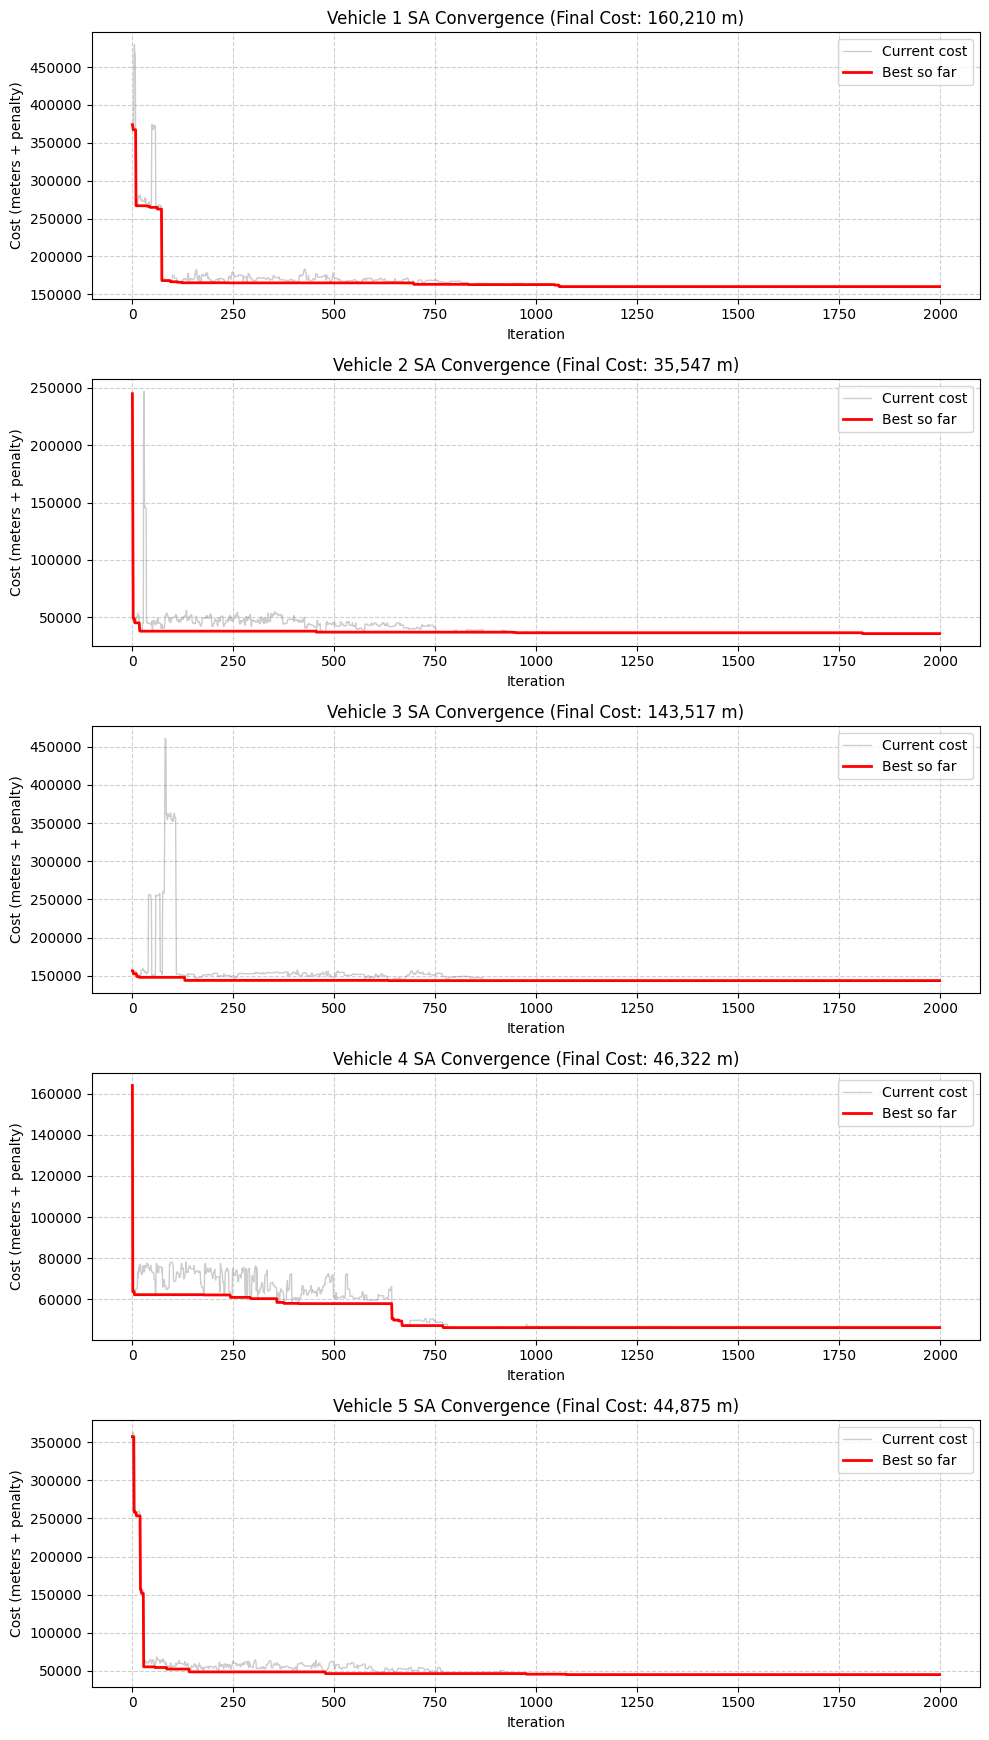

In [50]:

active_results = [r for r in vehicle_results if r['history']]
fig, axes = plt.subplots(
    nrows=max(1, len(active_results)), ncols=1,
    figsize=(10, 3.5 * max(1, len(active_results))), squeeze=False
)
for pi, r in enumerate(active_results):
    ax = axes[pi, 0]
    h = r['history']
    iters = range(len(h['best_so_far']))

    ax.plot(iters, h['current_cost'],
            label='Current cost', alpha=0.4, color='gray', linewidth=1)
    ax.plot(iters, h['best_so_far'],
            label='Best so far', color='red', linewidth=2)
            
    ax.set_title(f"Vehicle {r['vehicle_id']} SA Convergence (Final Cost: {r['cost']:,.0f} m)")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Cost (meters + penalty)")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("sa_convergence_improved.png", dpi=150, bbox_inches='tight')
plt.show()


## 9. Inspect Chosen Traversal Directions

In [51]:
def segment_orientation_summary(order, orientations, segments, D,
                                 water_source_indices, initial_ws_idx,
                                 tank_capacity=8000, avg_speed_kmh=30.0):
    def dist_to_time(dist_m):
        return (dist_m / 1000.0) / avg_speed_kmh * 60.0

    rows        = []
    current_time = float(OPERATION_START)
    cur_idx     = DEPOT_IDX
    water       = 0

    if initial_ws_idx is not None:
        current_time += dist_to_time(D[cur_idx, initial_ws_idx])
        cur_idx = initial_ws_idx
        water   = tank_capacity

    for step, (si, ori) in enumerate(zip(order, orientations), start=1):
        seg    = segments[si]
        demand = seg.get('demand', 0)
        entry  = seg['a_idx'] if ori == 0 else seg['b_idx']
        exit_  = seg['b_idx'] if ori == 0 else seg['a_idx']

        if water < demand and demand > 0:
            ws, wd = find_nearest_water_source(cur_idx, D, water_source_indices)
            current_time += dist_to_time(wd)
            cur_idx = ws
            water   = tank_capacity

        current_time += dist_to_time(D[cur_idx, entry])
        start_time    = current_time
        current_time += dist_to_time(D[entry, exit_]) + seg.get('service_time_min', 0.0)
        water        -= demand
        cur_idx       = exit_

        rows.append({
            "Step"      : step,
            "Segment"   : seg['name'],
            "Direction" : "A->B" if ori == 0 else "B->A",
            "Demand (L)": seg.get('demand', 0),
            "Start"     : time_to_str(start_time),
            "Finish"    : time_to_str(current_time),
        })

    return pd.DataFrame(rows)


for r in vehicle_results:
    if not r['seg_ids']: continue
    print(f"\nVehicle {r['vehicle_id']} route:")
    display(segment_orientation_summary(
        r['best_order'], r['orientations'], SEGMENTS,
        dist_matrix, WATER_SOURCE_INDICES, r['water_source_idx']
    ))


Vehicle 1 route:


,Step,Segment,Direction,Demand (L),Start,Finish
0,1,Jalan Kalijudan,B->A,9817.5,06:09,06:30
1,2,Jalan Kenjeran,A->B,5400.0,06:42,06:55
2,3,Jalan Raya Mulyosari,B->A,1725.0,07:00,07:08
3,4,Jalan Sukolilo Sukorejo,A->B,1350.0,07:19,07:23
4,5,Jalan Sukolilo Sukorejo,A->B,1350.0,07:23,07:27
5,6,Jalan Kenjeran,A->B,3600.0,07:28,07:38
6,7,Jalan Doktor Insinyur Haji Soekarno,A->B,6069.0,07:50,08:04
7,8,Jalan Doktor Insinyur Haji Soekarno,A->B,4725.0,08:11,08:22
8,9,Jalan Doktor Insinyur Haji Soekarno,A->B,1012.5,08:27,08:30
9,10,Jalan Kenjeran,A->B,2550.0,08:46,08:57



Vehicle 2 route:


,Step,Segment,Direction,Demand (L),Start,Finish
0,1,Jalan Profesor Doktor Moestopo,B->A,8167.5,06:11,06:30
1,2,Jalan Raya Dharmahusada Indah,B->A,28350.0,06:37,07:36
2,3,Jalan Dharma Husada Indah II,B->A,2460.0,07:41,07:47
3,4,Jalan Dharmahusada Indah III,A->B,2137.5,07:49,07:54
4,5,Jalan Dharmahusada Permai,B->A,4410.0,07:57,08:07
5,6,Jalan Dharmahusada Indah I,A->B,3000.0,08:12,08:19
6,7,Jalan Dharmahusada Indah I,A->B,3000.0,08:22,08:29
7,8,Jalan Dharmahusada Indah Utara XIV,B->A,3037.5,08:31,08:38
8,9,Jalan Dharmahusada Indah III,B->A,1950.0,08:40,08:45
9,10,Jalan Profesor Doktor Moestopo,A->B,675.0,08:53,08:55



Vehicle 3 route:


,Step,Segment,Direction,Demand (L),Start,Finish
0,1,Jalan Doktor Insinyur Haji Soekarno,B->A,5220.0,06:08,06:21
1,2,Jalan Semolowaru,B->A,2100.0,06:28,06:33
2,3,Jalan Nginden Semolo,B->A,3000.0,06:42,06:50
3,4,Jalan Arief Rahman Hakim,B->A,12285.0,06:56,07:22
4,5,Jalan Kedung Baruk,A->B,11865.0,07:29,07:55
5,6,Jalan Doktor Insinyur Haji Soekarno,B->A,7500.0,08:00,08:17
6,7,Jalan Arief Rahman Hakim,B->A,2857.5,08:20,08:30
7,8,Jalan Raya Kertajaya Indah (ITS - Oakwood),A->B,12825.0,08:35,09:03
8,9,Jalan Dharmahusada Indah III,B->A,2062.5,09:07,09:12
9,10,Jalan Raya Kertajaya Indah - Manyar Kertoarjo,A->B,30000.0,09:17,10:21



Vehicle 4 route:


,Step,Segment,Direction,Demand (L),Start,Finish
0,1,Jalan Penjaringan Asri II,B->A,5400.0,06:18,06:32
1,2,Jalan Medokan Asri Tengah,A->B,1350.0,06:32,06:35
2,3,Jalan Pandugo,B->A,1125.0,06:38,06:41
3,4,Jalan Doktor Insinyur Haji Soekarno,B->A,14250.0,06:51,07:23
4,5,Jalan Medokan Asri,B->A,1800.0,07:30,07:35
5,6,Jalan Penjaringan Sari,B->A,3000.0,07:36,07:43
6,7,Jalan Doktor Insinyur Haji Soekarno,B->A,8190.0,07:49,08:10
7,8,Jalan Raya ITS,A->B,6180.0,08:23,08:37
8,9,Jalan Dharma Husada Indah II,B->A,3000.0,08:43,08:50
9,10,Jalan Doktor Insinyur Haji Soekarno,A->B,7500.0,08:54,09:11



Vehicle 5 route:


,Step,Segment,Direction,Demand (L),Start,Finish
0,1,Jalan Raya Nginden,A->B,3840.0,06:07,06:16
1,2,Jalan Raya Menur,B->A,3487.5,06:23,06:32
2,3,Jalan Kertajaya,A->B,8910.0,06:38,06:57
3,4,Jalan Ngagel Jaya Utara,A->B,10125.0,07:06,07:28
4,5,Jalan Raya Nginden,A->B,4200.0,07:34,07:45
5,6,Jalan Raya Menur,B->A,3600.0,07:47,07:56
6,7,Jalan Ngagel Jaya,A->B,1125.0,08:03,08:06
7,8,Jalan Ngagel Jaya,A->B,1012.5,08:07,08:10
8,9,Jalan Airlangga,A->B,1912.5,08:15,08:21
9,10,Jalan Dharmawangsa,A->B,3300.0,08:21,08:31


## 10. Water Demand and Refill Simulation

Each vehicle starts at the depot with an empty tank, drives to its assigned water source to fill up (8000 L), then visits segments in order. Water is consumed per segment demand. When the tank is insufficient for the next segment, the vehicle detours to the nearest water source, refills, and continues.


In [52]:
for r in vehicle_results:
    if not r['seg_ids']: continue
    plan, td, rc, penalty = simulate_route_with_refills(
        r['best_order'], r['orientations'], SEGMENTS, dist_matrix,
        WATER_SOURCE_INDICES, r['water_source_idx'], r['tank_capacity'], RETURN_TO_DEPOT)
    r['refill_plan'] = plan
    r['total_dist_with_refills_m'] = td
    r['refill_count'] = rc
    r['time_penalty'] = penalty
    r['is_feasible']  = (penalty == 0.0)

    # Cetak ringkasan waktu per kendaraan
    # - sa_objective       : nilai cost yang dipakai SA selama optimasi (distance + refill + time penalty)
    # - reconstructed_dist : hasil simulate_route_with_refills yang dihitung ulang di sini (harus ~match sa_objective - penalty)
    print(f"\nVehicle {r['vehicle_id']:2d}: feasible={'YES' if r['is_feasible'] else 'NO'} | "
        f"sa_objective={r['total_dist_m']:,.0f}m | reconstructed_dist={td:,.0f}m | "
        f"refills={rc} | penalty={penalty:.0f} | demand={seg_demand:,.0f}L")
    for leg in plan:
        if leg['type'] == 'constraint_violation':
            print(f"   [VIOLATION] {leg['label']}")
        elif leg['type'] == 'drive_to_water':
            print(f"   REFILL: {leg['label']} (+{leg['distance_m']:,.0f}m)")


print(f"\n{'='*80}")
print("FLEET SUMMARY WITH REFILLS")
print(f"{'='*80}")
tfdr = sum(r.get('total_dist_with_refills_m', 0) for r in vehicle_results)
tr = sum(r.get('refill_count', 0) for r in vehicle_results)
for r in vehicle_results:
    if r['seg_ids']:
        print(f"  Vehicle {r['vehicle_id']:2d}: {r.get('total_dist_with_refills_m',0):>10,.0f} m "
              f"({r.get('total_dist_with_refills_m',0)/1000:.2f} km)  refills={r.get('refill_count',0)}")
print(f"  Fleet total : {tfdr:>10,.0f} m ({tfdr/1000:.2f} km)  total refills={tr}")



Vehicle  1: feasible=NO | sa_objective=160,210m | reconstructed_dist=60,210m | refills=9 | penalty=100000 | demand=52,200L
   REFILL: Depot -> Water Selokan Dekat Resto Niki Sae (initial fill) @ 06:06 (+3,194m)
   REFILL: Refill @ Water Selokan Dekat Resto Niki Sae (sisa=4000L) @ 06:06 (+0m)
   REFILL: Refill @ Water Selokan Dekat Resto Niki Sae (sisa=-5818L) @ 06:36 (+2,910m)
   [VIOLATION] [VIOLATION] Jalan Kenjeran @ 06:42: RUSH HOUR VIOLATION (arterial)
   REFILL: Refill @ Water Sungai Wisma Permai (sisa=-1400L) @ 07:02 (+3,092m)
   REFILL: Refill @ Water Sungai Wisma Permai (sisa=925L) @ 07:24 (+3,588m)
   REFILL: Refill @ Water Sungai Wisma Permai (sisa=2650L) @ 07:42 (+3,397m)
   REFILL: Refill @ Water Selokan Dekat Resto Niki Sae (sisa=400L) @ 08:04 (+3,122m)
   REFILL: Refill @ Water Selokan Dekat Resto Niki Sae (sisa=-2069L) @ 08:28 (+2,256m)
   REFILL: Refill @ Water Selokan Dekat Resto Niki Sae (sisa=-725L) @ 08:43 (+594m)

Vehicle  2: feasible=YES | sa_objective=35,547m |

## 11. Reconstruct Full Route Geometry with OSRM Route

In [53]:
route_cache = {}

def route_key(p1, p2):
    return (round(p1[0],6), round(p1[1],6), round(p2[0],6), round(p2[1],6))

def osrm_route(p1, p2, overview="full", geometries="geojson"):
    key = route_key(p1, p2)
    if key in route_cache: return route_cache[key]
    coords = f"{p1[1]:.6f},{p1[0]:.6f};{p2[1]:.6f},{p2[0]:.6f}"
    url = (f"{OSRM_BASE}/route/v1/{PROFILE}/{coords}"
           f"?overview={overview}&geometries={geometries}&steps=false")
    r = requests.get(url, timeout=120); r.raise_for_status()
    data = r.json()
    if data.get("code") != "Ok": raise RuntimeError(data)
    route = data["routes"][0]; geom = route["geometry"]["coordinates"]
    latlon = [(lat, lon) for lon, lat in geom]
    out = {"distance_m": float(route["distance"]), "duration_s": float(route["duration"]),
           "geometry_latlon": latlon, "raw": data}
    route_cache[key] = out
    return out

print("osrm_route helper ready.")

for r in vehicle_results:
    if not r['seg_ids']:
        r['full_route_coords'] = []; r['leg_summaries'] = []; continue
    frc = []; ls = []
    for i, leg in enumerate(r.get('refill_plan', []), start=1):
        if leg['type'] == 'constraint_violation':   # skip, tidak ada koordinat
            continue
        fp = SNAPPED_POINTS[leg['from_idx']]; tp = SNAPPED_POINTS[leg['to_idx']]
        res = osrm_route(fp, tp)
        geom = res['geometry_latlon']
        if frc and geom: geom = geom[1:]
        frc.extend(geom)
        ls.append({'leg_no':i, 'type':leg['type'], 'label':leg['label'],
                'distance_m':res['distance_m'], 'duration_min':res['duration_s']/60.0})
    r['full_route_coords'] = frc; r['leg_summaries'] = ls
    rtm = sum(x['distance_m'] for x in ls)
    print(f"Vehicle {r['vehicle_id']:2d}: SA={r['total_dist_m']:,.0f}m  "
          f"w/refills={r.get('total_dist_with_refills_m',0):,.0f}m  "
          f"OSRM_recon={rtm:,.0f}m  refills={r.get('refill_count',0)}")


osrm_route helper ready.


Vehicle  1: SA=160,210m  w/refills=60,210m  OSRM_recon=60,210m  refills=9
Vehicle  2: SA=35,547m  w/refills=35,547m  OSRM_recon=35,547m  refills=10
Vehicle  3: SA=143,517m  w/refills=43,517m  OSRM_recon=43,517m  refills=11
Vehicle  4: SA=46,322m  w/refills=46,322m  OSRM_recon=46,322m  refills=7
Vehicle  5: SA=44,875m  w/refills=44,875m  OSRM_recon=44,875m  refills=7


## 12. Visualize on Interactive OSM Map

In [54]:
output_dir = Path("Output")
output_dir.mkdir(exist_ok=True)

VEHICLE_COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
                  '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

def add_arrows(fmap, coords, color, n_arrows=6, arrow_size=12):
    if len(coords) < 2: return
    cd = [0.0]
    for i in range(1, len(coords)):
        cd.append(cd[-1] + math.hypot(coords[i][0]-coords[i-1][0], coords[i][1]-coords[i-1][1]))
    total = cd[-1]
    if total == 0: return
    for frac in [(k+1)/(n_arrows+1) for k in range(n_arrows)]:
        target = frac * total; si = 1
        while si < len(cd)-1 and cd[si] < target: si += 1
        sl = cd[si] - cd[si-1]; t = (target - cd[si-1])/sl if sl > 0 else 0
        lat = coords[si-1][0] + t*(coords[si][0]-coords[si-1][0])
        lon = coords[si-1][1] + t*(coords[si][1]-coords[si-1][1])
        dy, dx = coords[si][0]-coords[si-1][0], coords[si][1]-coords[si-1][1]
        b = math.degrees(math.atan2(dx, dy)) % 360
        html = (f'<div style="width:0;height:0;border-left:{arrow_size//2}px solid transparent;'
                f'border-right:{arrow_size//2}px solid transparent;'
                f'border-bottom:{arrow_size}px solid {color};'
                f'transform:rotate({b:.1f}deg);transform-origin:50% 100%;'
                f'opacity:0.85;margin-top:-{arrow_size}px;"></div>')
        folium.Marker((lat,lon), icon=folium.DivIcon(html=html, icon_size=(arrow_size,arrow_size))).add_to(fmap)

def build_vehicle_map(r_list, title_label="All Vehicles"):
    m = folium.Map(location=DEPOT, zoom_start=13,
        tiles='https://tile.openstreetmap.de/{z}/{x}/{y}.png', attr='OSM contributors')

    # Marker Depot Utama
    folium.Marker(DEPOT, tooltip='DEPOT', icon=folium.Icon(color='red', icon='home', prefix='fa')).add_to(m)

    for i_vehicle, r in enumerate(r_list):
        if not r['seg_ids']: continue

        vc = VEHICLE_COLORS[(r['vehicle_id']-1) % len(VEHICLE_COLORS)]
        vl = f"Vehicle {r['vehicle_id']}"

        # --- FITUR FILTER LAYER ---
        # Atur agar hanya rute pertama (index 0) yang tampil otomatis saat peta dibuka.
        # Sisanya disembunyikan (show=False) agar peta tidak penuh/kusut.
        is_visible = True if i_vehicle == 0 else False
        vehicle_group = folium.FeatureGroup(name=vl, show=is_visible)

        # Ambil rencana perjalanan lengkap (refill_plan)
        plan = r.get('refill_plan', [])

        for i, leg in enumerate(plan, start=1):
            if leg['type'] == 'constraint_violation':   # skip, tidak ada koordinat
                continue
            fp = SNAPPED_POINTS[leg['from_idx']]
            tp = SNAPPED_POINTS[leg['to_idx']]

            # Ambil rute asli jalan raya lewat OSRM
            res = osrm_route(fp, tp)

            # Tentukan gaya garis: Putus-putus jika sedang ambil air (Refill)
            line_dash = '10, 10' if leg['type'] == 'drive_to_water' else None

            # Gambar Garis Rute (dimasukkan ke vehicle_group, bukan m)
            folium.PolyLine(
                res['geometry_latlon'],
                color=vc,
                weight=4,
                opacity=0.8,
                dash_array=line_dash,
                tooltip=f"{vl} Langkah {i}: {leg['label']}"
            ).add_to(vehicle_group)

            # Penomoran di setiap titik henti
            icon_color = "blue" if leg['type'] == 'drive_to_water' else vc

            folium.Marker(
                tp,
                icon=folium.DivIcon(html=f'''
                    <div style="font-size:9pt; font-weight:bold; color:white;
                    background:{icon_color}; border:2px solid white; border-radius:5px;
                    padding:2px 5px; min-width:20px; text-align:center;
                    box-shadow:0 0 4px rgba(0,0,0,0.5);">
                        {i}
                    </div>'''),
                tooltip=f"{vl} Urutan ke-{i}: {leg['label']}"
            ).add_to(vehicle_group)

        # Tambahkan seluruh grup kendaraan ini ke peta
        vehicle_group.add_to(m)

    # Memunculkan kotak filter/Layer Control di pojok kanan atas
    folium.LayerControl(collapsed=False).add_to(m)

    return m

print("Generating combined map...")
m_all = build_vehicle_map(vehicle_results)
m_all.save(output_dir / "map_all_vehicles_SA.html")
print(f"  Saved: {output_dir / 'map_all_vehicles_SA.html'}")

active = [r for r in vehicle_results if r['seg_ids']]
print(f"Generating {len(active)} individual maps...")
for r in active:
    mv = build_vehicle_map([r])
    fn = output_dir / f"map_vehicle_{r['vehicle_id']}_SA.html"
    mv.save(fn); print(f"  Saved: {fn}")
print("\nDisplaying combined map:")
m_all


Generating combined map...
  Saved: Output\map_all_vehicles_SA.html
Generating 5 individual maps...
  Saved: Output\map_vehicle_1_SA.html
  Saved: Output\map_vehicle_2_SA.html
  Saved: Output\map_vehicle_3_SA.html
  Saved: Output\map_vehicle_4_SA.html
  Saved: Output\map_vehicle_5_SA.html

Displaying combined map:


### Detailed Result

In [55]:
r1 = next(r for r in vehicle_results if r['vehicle_id'] == 1)
print(f"Feasible: {r1['is_feasible']}")
print(f"Penalty : {r1['time_penalty']:.0f}")
print()
for leg in r1['refill_plan']:
    print(f"  [{leg['type']:<22}] {leg['label']}")

Feasible: False
Penalty : 100000

  [drive_to_water        ] Depot -> Water Selokan Dekat Resto Niki Sae (initial fill) @ 06:06
  [drive_to_water        ] Refill @ Water Selokan Dekat Resto Niki Sae (sisa=4000L) @ 06:06
  [drive_to_segment      ] Drive to Jalan Kalijudan entry @ 06:09
  [traverse_segment      ] Water Jalan Kalijudan (demand=9818L, selesai @ 06:30)
  [drive_to_water        ] Refill @ Water Selokan Dekat Resto Niki Sae (sisa=-5818L) @ 06:36
  [drive_to_segment      ] Drive to Jalan Kenjeran entry @ 06:42
  [constraint_violation  ] [VIOLATION] Jalan Kenjeran @ 06:42: RUSH HOUR VIOLATION (arterial)
  [traverse_segment      ] Water Jalan Kenjeran (demand=5400L, selesai @ 06:55)
  [drive_to_water        ] Refill @ Water Sungai Wisma Permai (sisa=-1400L) @ 07:02
  [drive_to_segment      ] Drive to Jalan Raya Mulyosari entry @ 07:03
  [traverse_segment      ] Water Jalan Raya Mulyosari (demand=1725L, selesai @ 07:11)
  [drive_to_segment      ] Drive to Jalan Sukolilo Sukorejo 

In [56]:
r2 = next(r for r in vehicle_results if r['vehicle_id'] == 2)
print(f"Feasible: {r2['is_feasible']}")
print(f"Penalty : {r2['time_penalty']:.0f}")
print()
for leg in r2['refill_plan']:
    print(f"  [{leg['type']:<22}] {leg['label']}")

Feasible: True
Penalty : 0

  [drive_to_water        ] Depot -> Water Selokan Dharmahusada Indah (initial fill) @ 06:03
  [drive_to_water        ] Refill @ Water Selokan Dharmahusada Indah (sisa=4000L) @ 06:03
  [drive_to_segment      ] Drive to Jalan Profesor Doktor Moestopo entry @ 06:11
  [traverse_segment      ] Water Jalan Profesor Doktor Moestopo (demand=8168L, selesai @ 06:30)
  [drive_to_water        ] Refill @ Water Selokan Dekat Resto Niki Sae (sisa=-4168L) @ 06:33
  [drive_to_segment      ] Drive to Jalan Raya Dharmahusada Indah entry @ 06:37
  [traverse_segment      ] Water Jalan Raya Dharmahusada Indah (demand=28350L, selesai @ 07:36)
  [drive_to_water        ] Refill @ Water Sungai Depan SPBU Manyar (Dekat RS Bedah) (sisa=-24350L) @ 07:37
  [drive_to_segment      ] Drive to Jalan Dharma Husada Indah II entry @ 07:41
  [traverse_segment      ] Water Jalan Dharma Husada Indah II (demand=2460L, selesai @ 07:47)
  [drive_to_water        ] Refill @ Water Selokan Dekat Resto Ni

In [57]:
r2 = next(r for r in vehicle_results if r['vehicle_id'] == 3)
print(f"Feasible: {r2['is_feasible']}")
print(f"Penalty : {r2['time_penalty']:.0f}")
print()
for leg in r2['refill_plan']:
    print(f"  [{leg['type']:<22}] {leg['label']}")

Feasible: False
Penalty : 100000

  [drive_to_water        ] Depot -> Water Sungai Depan ITATS (initial fill) @ 06:07
  [drive_to_water        ] Refill @ Water Sungai Depan ITATS (sisa=4000L) @ 06:07
  [drive_to_segment      ] Drive to Jalan Doktor Insinyur Haji Soekarno entry @ 06:08
  [traverse_segment      ] Water Jalan Doktor Insinyur Haji Soekarno (demand=5220L, selesai @ 06:21)
  [drive_to_water        ] Refill @ Water Selokan Dekat Resto Niki Sae (sisa=-1220L) @ 06:22
  [drive_to_segment      ] Drive to Jalan Semolowaru entry @ 06:32
  [traverse_segment      ] Water Jalan Semolowaru (demand=2100L, selesai @ 06:37)
  [drive_to_water        ] Refill @ Water Selokan Dekat Pizza Hut Merr (sisa=1900L) @ 06:42
  [drive_to_segment      ] Drive to Jalan Nginden Semolo entry @ 06:46
  [traverse_segment      ] Water Jalan Nginden Semolo (demand=3000L, selesai @ 06:54)
  [drive_to_water        ] Refill @ Water Sungai Seberang Apartemen Gunawangsa Menur (sisa=1000L) @ 06:58
  [drive_to_segm